# Session 06 — Regression Evaluation Metrics
### BrainerX AI Master Class

In this session, we will:
1. Load and explore the Car Price dataset
2. Clean and preprocess the data
3. Train multiple regression models
4. Evaluate them using key metrics: R², MAE, MSE, RMSE
5. Compare the models and visualize results

---
## Step 1 — Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, KFold
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

---
## Step 2 — About the Data

We want to predict the **price** of a car given its characteristics.

This is a **supervised regression** problem because:
- **Input (X)** = features like Year, Engine Size, Mileage, Make, Model, Fuel Type, Transmission
- **Output (y)** = a continuous number (Price, e.g. 25760.29)

The dataset has **1000 rows** and **8 columns**.

---
## Step 3 — Load the Dataset

In [2]:
# Load the dataset
df = pd.read_csv(r"C:\Users\j\Desktop\BrainerX\notebooks\datasets\Car_Price_Prediction.csv")

print(f"Dataset shape: {df.shape}")
print("\nFirst 5 rows:")
display(df.head())

Dataset shape: (1000, 8)

First 5 rows:


,Make,Model,Year,Engine Size,Mileage,Fuel Type,Transmission,Price
0,Honda,Model B,2015,3.9,74176,Petrol,Manual,30246.207931
1,Ford,Model C,2014,1.7,94799,Electric,Automatic,22785.747684
2,BMW,Model B,2006,4.1,98385,Electric,Manual,25760.290347
3,Honda,Model B,2015,2.6,88919,Electric,Automatic,25638.003491
4,Honda,Model C,2004,3.4,138482,Petrol,Automatic,21021.386657


In [3]:
# Check column types and missing values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Make          1000 non-null   object 
 1   Model         1000 non-null   object 
 2   Year          1000 non-null   int64  
 3   Engine Size   1000 non-null   float64
 4   Mileage       1000 non-null   int64  
 5   Fuel Type     1000 non-null   object 
 6   Transmission  1000 non-null   object 
 7   Price         1000 non-null   float64
dtypes: float64(2), int64(2), object(4)
memory usage: 62.6+ KB


In [24]:
# Summary statistics for numerical columns
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Engine Size,1000.0,2.79830,1.024137,1.000000,1.90000,2.800000,3.700000,4.500000
Mileage,1000.0,97192.48700,59447.315760,56.000000,44768.75000,94411.500000,148977.750000,199867.000000
Price,1000.0,25136.61553,5181.401368,6704.953524,21587.87837,25189.325247,28806.368974,41780.504635
vehicle_age,1000.0,14.31200,6.288577,4.000000,9.00000,14.000000,20.000000,25.000000


---
## Step 4 — Data Quality Report

Before preprocessing, it's good practice to run a quick "health check" on the data.

This function will automatically detect:
- Missing values
- Duplicate rows
- Constant columns (useless for a model)
- High-cardinality categorical columns
- Outliers (using the IQR method)

In [5]:
def report_dataframe(df: pd.DataFrame, high_card_limit: int = 50, verbose: bool = True) -> dict:
    report = {}

    def log(msg):
        if verbose:
            print(f"[INFO] {msg}")

    # 1. Missing values
    null_report = df.isnull().sum()
    null_report = null_report[null_report > 0]
    if not null_report.empty:
        log(f"Missing values found:\n{null_report}")
        report['missing_values'] = null_report.to_dict()
    else:
        log("No missing values found.")

    # 2. Duplicate rows
    dup_count = df.duplicated().sum()
    if dup_count > 0:
        log(f"Duplicate rows found: {dup_count}")
        report['duplicates'] = dup_count
    else:
        log("No duplicate rows found.")

    # 3. Constant columns
    constant_cols = [col for col in df.columns if df[col].nunique() == 1]
    if constant_cols:
        log(f"Constant columns (consider removing): {constant_cols}")
        report['constant_cols'] = constant_cols

    # 4. High-cardinality categoricals
    high_card_cols = [col for col in df.select_dtypes(include='object')
                      if df[col].nunique() > high_card_limit]
    if high_card_cols:
        log(f"High-cardinality columns: {high_card_cols}")
        report['high_cardinality'] = high_card_cols

    # 5. Numeric outliers (IQR method)
    num_cols = df.select_dtypes(include=np.number).columns
    outlier_report = {}
    for col in num_cols:
        q1, q3 = df[col].quantile([0.25, 0.75])
        iqr = q3 - q1
        lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
        outliers = df[(df[col] < lower) | (df[col] > upper)][col].count()
        if outliers > 0:
            outlier_report[col] = int(outliers)
    if outlier_report:
        log(f"Outliers detected:\n{outlier_report}")
        report['outliers'] = outlier_report

    log("Report complete.")
    return report

report = report_dataframe(df)

[INFO] No missing values found.
[INFO] No duplicate rows found.
[INFO] Outliers detected:
{'Price': 3}
[INFO] Report complete.


---
## Step 5 — Feature Engineering

Instead of keeping the raw `Year`, we create a new feature called `vehicle_age`.

**Why?** The age of the car is more meaningful to the model than the year alone.  
A car from 2020 is 5 years old today — that tells the model something concrete.

In [6]:
CURRENT_YEAR = 2025
df['vehicle_age'] = CURRENT_YEAR - df['Year']

# We can now drop Year since vehicle_age captures the same information
df = df.drop(columns=['Year'])

print("New column added: vehicle_age")
display(df.head())

New column added: vehicle_age


,Make,Model,Engine Size,Mileage,Fuel Type,Transmission,Price,vehicle_age
0,Honda,Model B,3.9,74176,Petrol,Manual,30246.207931,10
1,Ford,Model C,1.7,94799,Electric,Automatic,22785.747684,11
2,BMW,Model B,4.1,98385,Electric,Manual,25760.290347,19
3,Honda,Model B,2.6,88919,Electric,Automatic,25638.003491,10
4,Honda,Model C,3.4,138482,Petrol,Automatic,21021.386657,21


---
## Step 6 — Data Encoding

Machine learning models work with numbers only.  
We need to convert text columns (categorical) into numbers.

We have two strategies:
- **One-Hot Encoding** (via `pd.get_dummies`) — for columns with no order: Make, Model, Fuel Type
- **Label Encoding** — for binary columns (only 2 values): Transmission

In [7]:
# Let's first see what values are in each categorical column
categorical_cols = df.select_dtypes(include=['object']).columns

for col in categorical_cols:
    print(f"{col} → {df[col].unique()}")

Make → ['Honda' 'Ford' 'BMW' 'Audi' 'Toyota']
Model → ['Model B' 'Model C' 'Model A' 'Model D' 'Model E']
Fuel Type → ['Petrol' 'Electric' 'Diesel']
Transmission → ['Manual' 'Automatic']


In [8]:
# One-Hot Encoding for Make, Model, Fuel Type
# drop_first=True avoids the "dummy variable trap" (multicollinearity)
df_encoded = pd.get_dummies(df, columns=["Make", "Model", "Fuel Type"], drop_first=True)

display(df_encoded.head())

,Engine Size,Mileage,Transmission,Price,vehicle_age,Make_BMW,Make_Ford,Make_Honda,Make_Toyota,Model_Model B,Model_Model C,Model_Model D,Model_Model E,Fuel Type_Electric,Fuel Type_Petrol
0,3.9,74176,Manual,30246.207931,10,0,0,1,0,1,0,0,0,0,1
1,1.7,94799,Automatic,22785.747684,11,0,1,0,0,0,1,0,0,1,0
2,4.1,98385,Manual,25760.290347,19,1,0,0,0,1,0,0,0,1,0
3,2.6,88919,Automatic,25638.003491,10,0,0,1,0,1,0,0,0,1,0
4,3.4,138482,Automatic,21021.386657,21,0,0,1,0,0,1,0,0,0,1


In [9]:
# Label Encoding for Transmission (Manual=1, Automatic=0)
le = LabelEncoder()
df_encoded["Transmission"] = le.fit_transform(df_encoded["Transmission"])

display(df_encoded.head())

,Engine Size,Mileage,Transmission,Price,vehicle_age,Make_BMW,Make_Ford,Make_Honda,Make_Toyota,Model_Model B,Model_Model C,Model_Model D,Model_Model E,Fuel Type_Electric,Fuel Type_Petrol
0,3.9,74176,1,30246.207931,10,0,0,1,0,1,0,0,0,0,1
1,1.7,94799,0,22785.747684,11,0,1,0,0,0,1,0,0,1,0
2,4.1,98385,1,25760.290347,19,1,0,0,0,1,0,0,0,1,0
3,2.6,88919,0,25638.003491,10,0,0,1,0,1,0,0,0,1,0
4,3.4,138482,0,21021.386657,21,0,0,1,0,0,1,0,0,0,1


---
## Step 7 — Define X and y, then Split the Data

- **X** = all features (everything except Price)
- **y** = the target we want to predict (Price)

We then split into **train (75%)** and **test (25%)**.  
The model learns on the train set and is evaluated on the test set.

In [10]:
X = df_encoded.drop("Price", axis=1)
y = df_encoded["Price"]

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

X shape: (1000, 14)
y shape: (1000,)


In [11]:
# These are the columns we will scale (standardize)
numeric_cols = ["Engine Size", "Mileage", "vehicle_age"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

print(f"Train size: {X_train.shape[0]} rows")
print(f"Test size:  {X_test.shape[0]} rows")

Train size: 750 rows
Test size:  250 rows


---
## Step 8 — Feature Scaling

Some models (like Linear Regression and KNN) are sensitive to the **scale** of features.  
For example, Mileage can be 100,000 while Engine Size is 2.5 — that difference can distort the model.

**StandardScaler** transforms each numeric column to have:
- Mean = 0
- Standard Deviation = 1

**Important rule**: We `fit` the scaler only on the **training set**, then `transform` both train and test.  
This prevents data leakage from the test set.

In [12]:
scaler = StandardScaler()

# Fit on train, transform both
X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])

print("Scaling done. Preview of X_test:")
display(X_test.head())

Scaling done. Preview of X_test:


,Engine Size,Mileage,Transmission,vehicle_age,Make_BMW,Make_Ford,Make_Honda,Make_Toyota,Model_Model B,Model_Model C,Model_Model D,Model_Model E,Fuel Type_Electric,Fuel Type_Petrol
521,-0.971843,-1.388484,1,0.467888,0,0,0,0,1,0,0,0,0,0
737,-0.002842,-0.811769,1,-0.662536,0,0,0,0,0,0,0,1,0,1
740,-0.584243,-1.512169,0,0.467888,1,0,0,0,0,1,0,0,1,0
660,0.384758,0.719628,0,-1.147003,0,0,0,0,1,0,0,0,0,1
411,-0.390443,-0.644692,0,-0.501047,1,0,0,0,0,0,0,1,1,0


---
## Step 9 — Understanding the Evaluation Metrics

Before training the models, let's understand what we will use to measure performance:

| Metric | Formula | What it tells you |
|--------|---------|--------------------|
| **R²** (R-squared) | 1 - (SS_res / SS_tot) | How much of the variance the model explains. 1.0 = perfect, 0 = no better than predicting the mean |
| **MAE** (Mean Absolute Error) | mean(|y - ŷ|) | Average error in the same unit as the target (e.g. dollars) |
| **MSE** (Mean Squared Error) | mean((y - ŷ)²) | Like MAE but penalizes large errors more heavily |
| **RMSE** (Root MSE) | √MSE | Same unit as target — easier to interpret than MSE |

**For a good model we want:** R² close to 1, and MAE/RMSE as small as possible.

---
## Step 10 — Bonus: Cross-Validation (Linear Regression)

**Cross-validation** is a more reliable way to evaluate a model than a single train/test split.

With **5-Fold Cross-Validation**:
1. The data is split into 5 equal parts (folds)
2. In each round, 4 folds are used for training and 1 for testing
3. This is repeated 5 times so every fold gets used as a test set once
4. We report the **average** metric across all 5 rounds

This gives us a more honest picture of how the model performs on unseen data.

In [13]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

r2_scores, mae_scores, mse_scores, rmse_scores = [], [], [], []

print("=== 5-Fold Cross-Validation (Linear Regression) ===\n")

for fold, (train_idx, test_idx) in enumerate(kf.split(X), 1):
    # Split
    X_tr, X_te = X.iloc[train_idx], X.iloc[test_idx]
    y_tr, y_te = y.iloc[train_idx], y.iloc[test_idx]

    # Scale (fit ONLY on training fold)
    sc = StandardScaler()
    X_tr[numeric_cols] = sc.fit_transform(X_tr[numeric_cols])
    X_te[numeric_cols] = sc.transform(X_te[numeric_cols])

    # Train
    model = LinearRegression()
    model.fit(X_tr, y_tr)

    # Predict
    y_pred = model.predict(X_te)

    # Metrics
    r2  = r2_score(y_te, y_pred)
    mae = mean_absolute_error(y_te, y_pred)
    mse = mean_squared_error(y_te, y_pred)
    rmse = np.sqrt(mse)

    r2_scores.append(r2)
    mae_scores.append(mae)
    mse_scores.append(mse)
    rmse_scores.append(rmse)

    print(f"Fold {fold}: R²={r2:.3f} | MAE={mae:.1f} | RMSE={rmse:.1f}")

print(f"\n--- Average Results ---")
print(f"R²  : {np.mean(r2_scores):.4f}  (± {np.std(r2_scores):.4f})")
print(f"MAE : {np.mean(mae_scores):.2f}")
print(f"MSE : {np.mean(mse_scores):.2f}")
print(f"RMSE: {np.mean(rmse_scores):.2f}")

=== 5-Fold Cross-Validation (Linear Regression) ===

Fold 1: R²=0.817 | MAE=1810.6 | RMSE=2237.3
Fold 2: R²=0.831 | MAE=1615.8 | RMSE=2082.2
Fold 3: R²=0.854 | MAE=1634.0 | RMSE=2039.8
Fold 4: R²=0.837 | MAE=1607.3 | RMSE=2066.3
Fold 5: R²=0.826 | MAE=1658.2 | RMSE=2088.8

--- Average Results ---
R²  : 0.8331  (± 0.0125)
MAE : 1665.17
MSE : 4426894.75
RMSE: 2102.88


---
## Step 11 — Train and Evaluate All Models

We will now train 4 models on the same train/test split and compare their scores.

### Model 1 — Linear Regression

The simplest regression model. It assumes the relationship between features and price is **linear**:

```
Price = intercept + coef1 × feature1 + coef2 × feature2 + ...
```

In [14]:
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

print("=== Linear Regression ===")
print(f"R²  : {r2_score(y_test, y_pred_lr):.4f}")
print(f"MAE : {mean_absolute_error(y_test, y_pred_lr):.2f}")
print(f"MSE : {mean_squared_error(y_test, y_pred_lr):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_lr)):.2f}")

=== Linear Regression ===
R²  : 0.8286
MAE : 1718.71
MSE : 4562401.26
RMSE: 2135.98


In [15]:
# The intercept is the predicted price when all feature values are 0
print(f"Intercept: {lr.intercept_:.2f}")

# The coefficients show how much each feature pushes the price up or down
coef_df = pd.DataFrame({'Feature': X_train.columns, 'Coefficient': lr.coef_})
coef_df = coef_df.sort_values('Coefficient', ascending=False)
display(coef_df)

Intercept: 25193.99


,Feature,Coefficient
0,Engine Size,2033.068771
10,Model_Model D,234.845813
5,Make_Ford,146.629806
4,Make_BMW,78.816808
7,Make_Toyota,43.413578
2,Transmission,15.461096
13,Fuel Type_Petrol,11.583571
8,Model_Model B,-29.179232
9,Model_Model C,-51.544994
12,Fuel Type_Electric,-99.672574


### Model 2 — Decision Tree Regressor

A Decision Tree learns a series of **if/else rules** from the training data.  
It's easy to understand but can overfit (memorize the training data too well).

In [16]:
dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

print("=== Decision Tree ===")
print(f"R²  : {r2_score(y_test, y_pred_dt):.4f}")
print(f"MAE : {mean_absolute_error(y_test, y_pred_dt):.2f}")
print(f"MSE : {mean_squared_error(y_test, y_pred_dt):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_dt)):.2f}")

=== Decision Tree ===
R²  : 0.6324
MAE : 2445.00
MSE : 9785932.74
RMSE: 3128.25


### Model 3 — Random Forest Regressor

Random Forest builds **many Decision Trees** and averages their predictions.  
This reduces overfitting and usually gives better results than a single tree.

`n_estimators=100` means we build 100 trees.

In [17]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("=== Random Forest ===")
print(f"R²  : {r2_score(y_test, y_pred_rf):.4f}")
print(f"MAE : {mean_absolute_error(y_test, y_pred_rf):.2f}")
print(f"MSE : {mean_squared_error(y_test, y_pred_rf):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_rf)):.2f}")

=== Random Forest ===
R²  : 0.7981
MAE : 1882.93
MSE : 5373234.94
RMSE: 2318.02


### Model 4 — K-Nearest Neighbors (KNN)

KNN predicts a value by looking at the **k closest training examples** and averaging their prices.  
Here we use `k=7`, meaning we look at the 7 nearest neighbors.

In [18]:
knn = KNeighborsRegressor(n_neighbors=7)
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)

print("=== KNN Regressor ===")
print(f"R²  : {r2_score(y_test, y_pred_knn):.4f}")
print(f"MAE : {mean_absolute_error(y_test, y_pred_knn):.2f}")
print(f"MSE : {mean_squared_error(y_test, y_pred_knn):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_knn)):.2f}")

=== KNN Regressor ===
R²  : 0.7459
MAE : 2085.44
MSE : 6763146.15
RMSE: 2600.60


---
## Step 12 — Compare All Models

Let's put all the results in one table to compare them side by side.

In [19]:
results = {
    "Model": ["Linear Regression", "Decision Tree", "Random Forest", "KNN"],
    "R²": [
        r2_score(y_test, y_pred_lr),
        r2_score(y_test, y_pred_dt),
        r2_score(y_test, y_pred_rf),
        r2_score(y_test, y_pred_knn)
    ],
    "MAE": [
        mean_absolute_error(y_test, y_pred_lr),
        mean_absolute_error(y_test, y_pred_dt),
        mean_absolute_error(y_test, y_pred_rf),
        mean_absolute_error(y_test, y_pred_knn)
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(y_test, y_pred_lr)),
        np.sqrt(mean_squared_error(y_test, y_pred_dt)),
        np.sqrt(mean_squared_error(y_test, y_pred_rf)),
        np.sqrt(mean_squared_error(y_test, y_pred_knn))
    ]
}

results_df = pd.DataFrame(results)
results_df = results_df.sort_values("R²", ascending=False).reset_index(drop=True)
results_df["R²"]   = results_df["R²"].round(4)
results_df["MAE"]  = results_df["MAE"].round(2)
results_df["RMSE"] = results_df["RMSE"].round(2)

display(results_df)

,Model,R²,MAE,RMSE
0,Linear Regression,0.8286,1718.71,2135.98
1,Random Forest,0.7981,1882.93,2318.02
2,KNN,0.7459,2085.44,2600.60
3,Decision Tree,0.6324,2445.00,3128.25


---
## Step 13 — Visualization

### Plot 1 — Predicted vs Actual Prices (Linear Regression)

If the model is perfect, all dots would fall on the red dashed line.  
The closer the dots are to the line, the better the model.

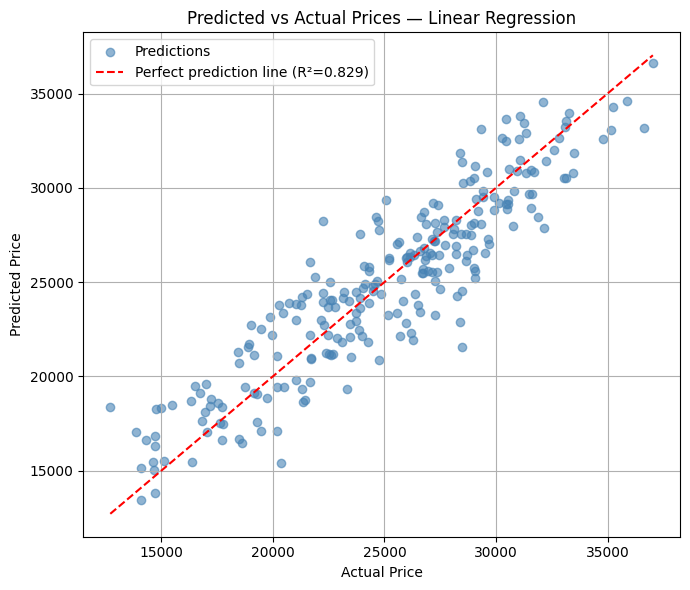

In [20]:
plt.figure(figsize=(7, 6))
plt.scatter(y_test, y_pred_lr, color='steelblue', alpha=0.6, label='Predictions')
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--',
    label=f'Perfect prediction line (R²={r2_score(y_test, y_pred_lr):.3f})'
)
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Predicted vs Actual Prices — Linear Regression')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### Plot 2 — R² Comparison Across Models

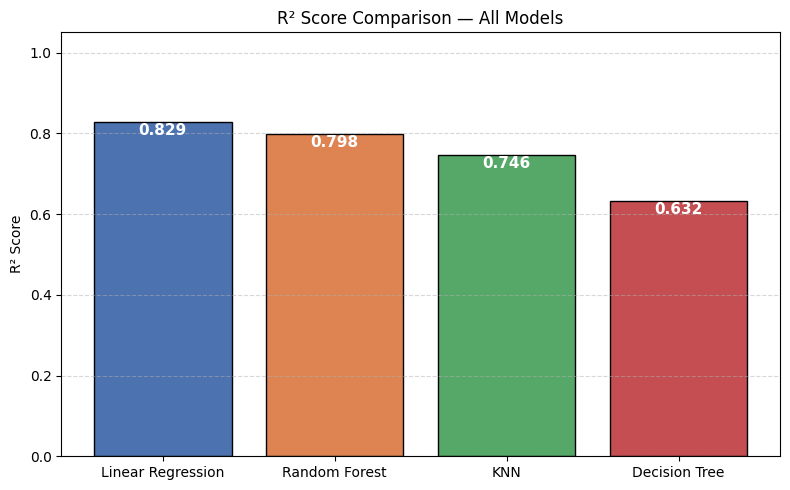

In [21]:
plt.figure(figsize=(8, 5))
colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']
bars = plt.bar(results_df["Model"], results_df["R²"], color=colors, edgecolor='black')

for bar, val in zip(bars, results_df["R²"]):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() - 0.04,
             f'{val:.3f}', ha='center', va='bottom', fontsize=11, color='white', fontweight='bold')

plt.ylim(0, 1.05)
plt.ylabel('R² Score')
plt.title('R² Score Comparison — All Models')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### Plot 3 — RMSE Comparison Across Models

RMSE is in dollars — a lower bar means the model makes smaller average errors.

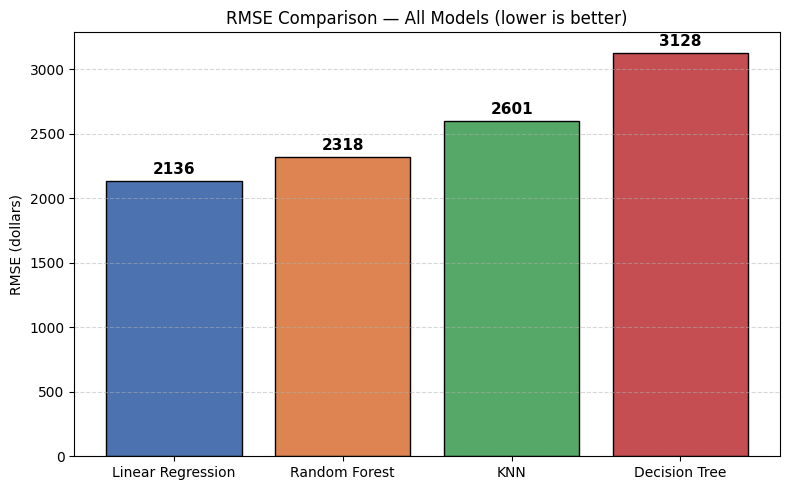

In [22]:
plt.figure(figsize=(8, 5))
bars = plt.bar(results_df["Model"], results_df["RMSE"], color=colors, edgecolor='black')

for bar, val in zip(bars, results_df["RMSE"]):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 30,
             f'{val:.0f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.ylabel('RMSE (dollars)')
plt.title('RMSE Comparison — All Models (lower is better)')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

---
## Step 14 — Summary

Here is what we did in this session, step by step:

1. **Loaded** the Car Price dataset (1000 rows, 8 columns)
2. **Explored** the data with `.info()`, `.describe()`, and a quality report
3. **Engineered** a new feature: `vehicle_age = 2025 - Year`
4. **Encoded** categorical columns with One-Hot Encoding and Label Encoding
5. **Split** the data into train (75%) and test (25%)
6. **Scaled** numerical features using StandardScaler
7. **Evaluated** Linear Regression using 5-Fold Cross-Validation
8. **Trained** 4 models: Linear Regression, Decision Tree, Random Forest, KNN
9. **Compared** them using R², MAE, MSE, RMSE
10. **Visualized** the results with scatter plots and bar charts

**Key takeaway**: Linear Regression performed best on this dataset, with the highest R² and lowest RMSE. Decision Tree overfits — it memorizes the training data but performs poorly on new data.